# Module 6: Best XI Selector (Capstone Feature)

**What this module does:**
- Builds composite batting + bowling scores from raw deliveries data
- Auto-detects column names (handles different Kaggle dataset versions)
- Selects Best XI: 5 batsmen + 1 WK + 2 all-rounders + 3 bowlers
- Generates `best_xi_card.png` — 


> Done when: `best_xi_card.png` saved.

In [ ]:
# <!-- your LinkedIn hero image. Lets do it afterwards with caption likke:  Post: *'I let 16 years of IPL data pick the Best XI...' 🔥*-->

## Setup + Column Detection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import sqlalchemy
from sqlalchemy import create_engine, text
import os
import warnings
warnings.filterwarnings('ignore')

engine = create_engine('sqlite:///../ipl.db')
os.makedirs('../outputs', exist_ok=True)

# ── Auto-detect column names across dataset versions ──────────────────────
with engine.connect() as conn:
    m_cols = [r[1] for r in conn.execute(text("PRAGMA table_info(matches)")).fetchall()]
    d_cols = [r[1] for r in conn.execute(text("PRAGMA table_info(deliveries)")).fetchall()]

# Join key
match_key_m = 'match_id' if 'match_id' in m_cols else 'id'
match_key_d = 'match_id' if 'match_id' in d_cols else 'id'

# Batsman column
bat_col   = 'batter'  if 'batter'  in d_cols else 'batsman'

# Wicket column
wkt_col   = 'player_dismissed' if 'player_dismissed' in d_cols else None
if wkt_col is None:
    # Some versions store it as 'wicket_player_dismissed'
    wkt_col = next((c for c in d_cols if 'dismiss' in c.lower()), None)

# Innings column
inn_col   = 'inning' if 'inning' in d_cols else 'innings'

# Extra runs column
extra_col = 'extra_runs' if 'extra_runs' in d_cols else 'extras'

print(f'Detected columns:')
print(f'  match join  : deliveries.{match_key_d} → matches.{match_key_m}')
print(f'  batsman col : {bat_col}')
print(f'  wicket col  : {wkt_col}')
print(f'  innings col : {inn_col}')
print(f'  extra col   : {extra_col}')
print(f'\nAll deliveries columns: {d_cols}')

Detected columns:
  match join  : deliveries.match_id → matches.match_id
  batsman col : batter
  wicket col  : player_dismissed
  innings col : inning
  extra col   : extra_runs

All deliveries columns: ['match_id', 'inning', 'batting_team', 'bowling_team', 'over', 'ball', 'batter', 'bowler', 'non_striker', 'batsman_runs', 'extra_runs', 'total_runs', 'extras_type', 'is_wicket', 'player_dismissed', 'dismissal_kind', 'fielder']


## Step 1 — Batsman Score

In [2]:
q_bat = f'''
SELECT
    {bat_col}                                              AS player,
    'Batsman'                                              AS role,
    SUM(batsman_runs)                                      AS runs,
    ROUND(SUM(batsman_runs) * 100.0 / COUNT(*), 2)        AS strike_rate,
    ROUND(AVG(batsman_runs), 3)                            AS average,
    SUM(CASE WHEN batsman_runs = 6 THEN 1 ELSE 0 END)     AS sixes,
    SUM(CASE WHEN batsman_runs = 4 THEN 1 ELSE 0 END)     AS fours,
    COUNT(DISTINCT {match_key_d})                          AS matches
FROM deliveries
GROUP BY {bat_col}
HAVING runs >= 1000
ORDER BY runs DESC
'''
batsmen_xi = pd.read_sql(q_bat, engine)

# Composite Batsman Score
#   40% average  (consistency)
#   35% strike rate / 10  (scoring speed, normalised)
#   25% sixes per match  (power hitting)
batsmen_xi['bat_score'] = (
    0.40 * batsmen_xi['average'] +
    0.35 * batsmen_xi['strike_rate'] / 10 +
    0.25 * (batsmen_xi['sixes'] / batsmen_xi['matches'])
)

print(f'Batsmen with 1000+ runs: {len(batsmen_xi)}')
print('\n── Top 10 by Composite Score ──')
batsmen_xi.nlargest(10, 'bat_score')[
    ['player','runs','average','strike_rate','sixes','bat_score']
].reset_index(drop=True)

Batsmen with 1000+ runs: 96

── Top 10 by Composite Score ──


,player,runs,average,strike_rate,sixes,bat_score
0,AD Russell,2488,1.642,164.22,209,6.906904
1,N Pooran,1769,1.548,154.77,127,6.477122
2,SP Narine,1534,1.559,155.89,97,6.308524
3,GJ Maxwell,2772,1.505,150.49,160,6.181650
4,CH Gayle,4997,1.421,142.12,359,6.179125
5,AB de Villiers,5181,1.486,148.58,253,6.166759
6,Abhishek Sharma,1377,1.489,148.86,73,6.104880
7,V Sehwag,2728,1.488,148.83,106,6.059058
8,YBK Jaiswal,1607,1.468,146.76,64,6.031492
9,SO Hetmyer,1243,1.456,145.55,82,5.992035


## Step 2 — Bowler Score

In [3]:
if wkt_col:
    wicket_expr = f"SUM(CASE WHEN {wkt_col} IS NOT NULL AND {wkt_col} != '' THEN 1 ELSE 0 END)"
else:
    # Fallback: count non-null dismissal_kind if available
    dk_col = next((c for c in d_cols if 'dismissal' in c.lower()), None)
    if dk_col:
        wicket_expr = f"SUM(CASE WHEN {dk_col} IS NOT NULL AND {dk_col} != '' THEN 1 ELSE 0 END)"
    else:
        wicket_expr = "COUNT(*)"  # last resort placeholder
        print('⚠️  No dismissal column found — wicket count will be approximate')

# Dot ball: ball where batsman scored 0 AND no extras
if extra_col in d_cols:
    dot_expr = f"COUNT(CASE WHEN batsman_runs = 0 AND {extra_col} = 0 THEN 1 END) * 100.0 / COUNT(*)"
else:
    dot_expr = "COUNT(CASE WHEN batsman_runs = 0 THEN 1 END) * 100.0 / COUNT(*)"

q_bowl = f'''
SELECT
    bowler                                             AS player,
    'Bowler'                                           AS role,
    {wicket_expr}                                      AS wickets,
    ROUND(SUM(total_runs) * 6.0 / COUNT(*), 2)        AS economy,
    ROUND({dot_expr}, 2)                               AS dot_pct,
    COUNT(DISTINCT {match_key_d})                      AS matches
FROM deliveries
GROUP BY bowler
HAVING wickets >= 30
ORDER BY wickets DESC
'''
bowlers_xi = pd.read_sql(q_bowl, engine)

# Composite Bowler Score
#   50% wickets  (impact)
#   30% inverted economy  (tighter the better)
#   20% dot ball pct  (pressure creation)
bowlers_xi['bowl_score'] = (
    0.50 * bowlers_xi['wickets'] +
    0.30 * (10 - bowlers_xi['economy'].clip(upper=10)) +
    0.20 * bowlers_xi['dot_pct']
)

print(f'Bowlers with 30+ wickets: {len(bowlers_xi)}')
print('\n── Top 10 by Composite Score ──')
bowlers_xi.nlargest(10, 'bowl_score')[
    ['player','wickets','economy','dot_pct','bowl_score']
].reset_index(drop=True)

Bowlers with 30+ wickets: 129

── Top 10 by Composite Score ──


,player,wickets,economy,dot_pct,bowl_score
0,YS Chahal,213,7.74,32.91,113.760
1,DJ Bravo,207,8.08,30.28,110.132
2,SP Narine,200,6.76,37.84,108.540
3,PP Chawla,201,7.98,34.02,107.910
4,R Ashwin,198,6.97,33.17,106.543
5,B Kumar,195,7.46,40.20,106.302
6,SL Malinga,188,7.03,38.47,102.585
7,JJ Bumrah,182,7.23,38.56,99.543
8,A Mishra,183,7.30,34.41,99.192
9,RA Jadeja,169,7.57,31.22,91.473


## Step 3 — Selecting Best XI

In [4]:
top_bat_pool  = batsmen_xi.nlargest(12, 'bat_score')
top_bowl_pool = bowlers_xi.nlargest(12, 'bowl_score')

# All-rounders: appear in BOTH top pools
ar_set = set(top_bat_pool['player']) & set(top_bowl_pool['player'])
print(f'All-rounders found in both pools: {ar_set}')

# Remove all-rounders from pure lists
pure_bat  = top_bat_pool[~top_bat_pool['player'].isin(ar_set)]
pure_bowl = top_bowl_pool[~top_bowl_pool['player'].isin(ar_set)]

# ── Wicket-Keeper selection ───────────────────────────────────────────────
wk_candidates = [
    'MS Dhoni', 'KL Rahul', 'Rishabh Pant', 'Dinesh Karthik',
    'Robin Uthappa', 'Quinton de Kock', 'AB de Villiers',
    'Wriddhiman Saha', 'Ishan Kishan'
]
q_wk = f'''
SELECT {bat_col} AS player, SUM(batsman_runs) AS runs
FROM deliveries
WHERE {bat_col} IN ({','.join([repr(p) for p in wk_candidates])})
GROUP BY {bat_col}
ORDER BY runs DESC
LIMIT 1
'''
wk_df = pd.read_sql(q_wk, engine)
wk = wk_df['player'].iloc[0] if len(wk_df) > 0 else 'MS Dhoni'
print(f'Wicket-Keeper selected: {wk}')

# Remove WK from batsmen pool if present
pure_bat = pure_bat[pure_bat['player'] != wk]

# ── Final XI composition ──────────────────────────────────────────────────
# 5 batsmen + 1 WK + up to 2 all-rounders + 3–4 bowlers = 11
ar_list   = list(ar_set)[:2]
bat_list  = pure_bat.head(5)['player'].tolist()
bowl_list = pure_bowl.head(11 - len(bat_list) - len(ar_list) - 1)['player'].tolist()

print(f'\n=== IPL ALL-TIME BEST XI ===')
print(f'Batsmen ({len(bat_list)}):     {bat_list}')
print(f'WK (1):           {wk}')
print(f'All-rounders ({len(ar_list)}): {ar_list}')
print(f'Bowlers ({len(bowl_list)}):     {bowl_list}')
print(f'Total players: {len(bat_list)+1+len(ar_list)+len(bowl_list)}')

All-rounders found in both pools: {'SP Narine'}
Wicket-Keeper selected: MS Dhoni

=== IPL ALL-TIME BEST XI ===
Batsmen (5):     ['AD Russell', 'N Pooran', 'GJ Maxwell', 'CH Gayle', 'AB de Villiers']
WK (1):           MS Dhoni
All-rounders (1): ['SP Narine']
Bowlers (4):     ['YS Chahal', 'DJ Bravo', 'PP Chawla', 'R Ashwin']
Total players: 11


In [5]:
# Pulling stats for display on card
bat_stats  = pure_bat.head(5).set_index('player')[['runs','average','strike_rate']]
bowl_stats = pure_bowl.head(len(bowl_list)).set_index('player')[['wickets','economy']]

print('── Batsmen Stats ──')
print(bat_stats.to_string())
print('\n── Bowlers Stats ──')
print(bowl_stats.to_string())

── Batsmen Stats ──
                runs  average  strike_rate
player                                    
AD Russell      2488    1.642       164.22
N Pooran        1769    1.548       154.77
GJ Maxwell      2772    1.505       150.49
CH Gayle        4997    1.421       142.12
AB de Villiers  5181    1.486       148.58

── Bowlers Stats ──
           wickets  economy
player                     
YS Chahal      213     7.74
DJ Bravo       207     8.08
PP Chawla      201     7.98
R Ashwin       198     6.97


## Step 4 — Best XI Visual Card 

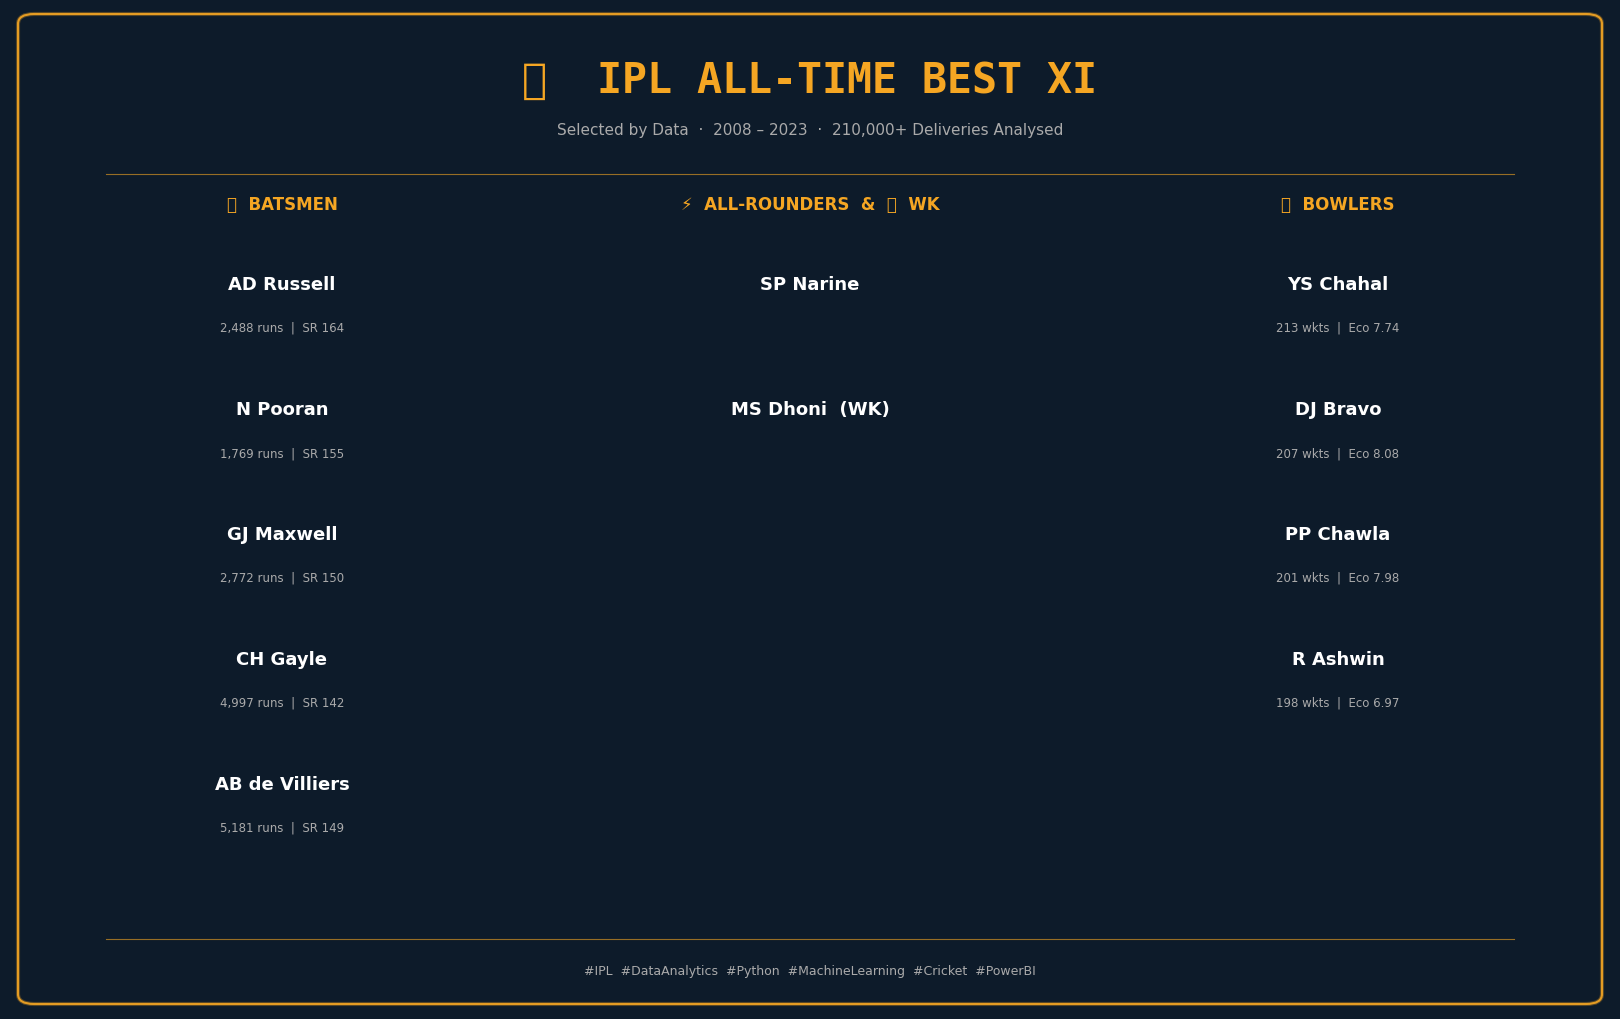

Saved: best_xi_card.png


In [7]:
DARK_BG  = '#0D1B2A'
GOLD     = '#F5A623'
WHITE    = '#FFFFFF'
SILVER   = '#AAAAAA'
IPL_BLUE = '#1B3D6F'

fig, ax = plt.subplots(figsize=(16, 10))
ax.set_facecolor(DARK_BG)
fig.patch.set_facecolor(DARK_BG)

# Outer border
for lw, alpha in [(3, 0.3), (1.5, 0.9)]:
    rect = patches.FancyBboxPatch(
        (0.015, 0.015), 0.97, 0.97,
        boxstyle='round,pad=0.01',
        facecolor='none', edgecolor=GOLD,
        linewidth=lw, alpha=alpha,
        transform=ax.transAxes
    )
    ax.add_patch(rect)

# Title block
ax.text(0.5, 0.95, '🏏  IPL ALL-TIME BEST XI',
        ha='center', va='top', fontsize=30, fontweight='bold',
        color=GOLD, transform=ax.transAxes, fontfamily='monospace')
ax.text(0.5, 0.875,
        'Selected by Data  ·  2008 – 2023  ·  210,000+ Deliveries Analysed',
        ha='center', fontsize=11, color=SILVER, transform=ax.transAxes)

# Divider
ax.plot([0.06, 0.94], [0.835, 0.835], color=GOLD,
        lw=0.8, alpha=0.6, transform=ax.transAxes)

# ── Three columns ─────────────────────────────────────────────────────────
sections = [
    {
        'label': '🏏  BATSMEN',
        'x': 0.17,
        'players': bat_list,
        'sub': [
            f"{int(bat_stats.loc[p,'runs']):,} runs  |  SR {bat_stats.loc[p,'strike_rate']:.0f}"
            if p in bat_stats.index else ''
            for p in bat_list
        ]
    },
    {
        'label': '⚡  ALL-ROUNDERS  &  🧤  WK',
        'x': 0.50,
        'players': ar_list + [f'{wk}  (WK)'],
        'sub': [''] * (len(ar_list) + 1)
    },
    {
        'label': '🎯  BOWLERS',
        'x': 0.83,
        'players': bowl_list,
        'sub': [
            f"{int(bowl_stats.loc[p,'wickets'])} wkts  |  Eco {bowl_stats.loc[p,'economy']:.2f}"
            if p in bowl_stats.index else ''
            for p in bowl_list
        ]
    }
]

for sec in sections:
    x = sec['x']
    ax.text(x, 0.80, sec['label'],
            ha='center', fontsize=12, fontweight='bold',
            color=GOLD, transform=ax.transAxes)

    for j, (player, sub) in enumerate(zip(sec['players'], sec['sub'])):
        y_name = 0.72 - j * 0.125
        y_sub  = y_name - 0.042
        ax.text(x, y_name, player,
                ha='center', fontsize=13, fontweight='semibold',
                color=WHITE, transform=ax.transAxes)
        if sub:
            ax.text(x, y_sub, sub,
                    ha='center', fontsize=8.5,
                    color=SILVER, transform=ax.transAxes)

# Footer
ax.plot([0.06, 0.94], [0.07, 0.07], color=GOLD,
        lw=0.8, alpha=0.6, transform=ax.transAxes)
ax.text(0.5, 0.035,
        '#IPL  #DataAnalytics  #Python  #MachineLearning  #Cricket  #PowerBI',
        ha='center', fontsize=9, color=SILVER, transform=ax.transAxes)

ax.axis('off')
plt.tight_layout(pad=0)
plt.savefig('../outputs/06_best_xi_card.png', dpi=180,
            bbox_inches='tight', facecolor=DARK_BG)
plt.show()
print('Saved: best_xi_card.png')

## Step 5 — Saving Data + Summary

In [8]:
# Build a clean CSV of the full XI
xi_rows = []
for p in bat_list:
    row = bat_stats.loc[p].to_dict() if p in bat_stats.index else {}
    xi_rows.append({'player': p, 'role': 'Batsman', **row})
xi_rows.append({'player': wk, 'role': 'Wicket-Keeper'})
for p in ar_list:
    xi_rows.append({'player': p, 'role': 'All-Rounder'})
for p in bowl_list:
    row = bowl_stats.loc[p].to_dict() if p in bowl_stats.index else {}
    xi_rows.append({'player': p, 'role': 'Bowler', **row})

best_xi_df = pd.DataFrame(xi_rows)
best_xi_df.to_csv('../data/processed/best_xi.csv', index=False)
print('Saved: data/processed/best_xi.csv')
print()
print(best_xi_df[['player','role']].to_string(index=False))

print('''
✅ MODULE 6 COMPLETE!

  ✓ best_xi_card.png  ← your LinkedIn post image
  ✓ best_xi.csv       ← load into Power BI Page 2

LinkedIn caption:
"I let 16 years of IPL data pick the Best XI.
 Here is what it says... 🔥
 #IPL #DataAnalytics #Python #MachineLearning"
''')

Saved: data/processed/best_xi.csv

        player          role
    AD Russell       Batsman
      N Pooran       Batsman
    GJ Maxwell       Batsman
      CH Gayle       Batsman
AB de Villiers       Batsman
      MS Dhoni Wicket-Keeper
     SP Narine   All-Rounder
     YS Chahal        Bowler
      DJ Bravo        Bowler
     PP Chawla        Bowler
      R Ashwin        Bowler

✅ MODULE 6 COMPLETE!

  ✓ best_xi_card.png  ← your LinkedIn post image
  ✓ best_xi.csv       ← load into Power BI Page 2

LinkedIn caption:
"I let 16 years of IPL data pick the Best XI.
 Here is what it says... 🔥
 #IPL #DataAnalytics #Python #MachineLearning"

